# CONUS Great Plain domain forecast checks

In [1]:
import os
import re
import sys
import yaml
import argparse
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [4]:
need_publish = True

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

## Prep data

In [5]:
my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = my_colors['cyan']
blue = my_colors['blue']
green = my_colors['green']
red = my_colors['red']
orange = my_colors['orange']

In [6]:
cmap_TC = plt.get_cmap("hot")

C1 = colors.to_hex(cmap_TC(0.7))
C2 = colors.to_hex(cmap_TC(0.6))
C3 = colors.to_hex(cmap_TC(0.5))
C4 = colors.to_hex(cmap_TC(0.4))
C5 = colors.to_hex(cmap_TC(0.3))

In [7]:
# standard SSHWS palette
# SSHWS_COLORS = {-1: "#5EBAFF", 0: "#00FAF4", 1: "#FFFFB2", 2: "#FFE775",
#                 3: "#FFC140", 4: "#FF8F20", 5: "#FF6060"}
SSHWS_COLORS = {-1: "#5EBAFF", 0: "#00FAF4", 1: C1, 2: C2,
                3: C3, 4: C4, 5: C5}

SSHWS_LABEL = {-1: "TD", 0: "TS", 1: "Cat 1", 2: "Cat 2",
               3: "Cat 3", 4: "Cat 4", 5: "Cat 5"}

# trivial one-liners (not the "big functions" you wanted gone)
cat_color = lambda c: SSHWS_COLORS.get(int(c), "#9e9e9e")
fmt_t = lambda s: datetime.strptime(s, "%Y-%m-%d %H:%M").strftime("%b-%d %HZ")

In [8]:
# %% cases
raw_cases = [
    # season, hurdat_id, storm, category, track_start, track_end
    (2020, "AL082020", "Hanna",    1, "2020-07-23 00:00", "2020-07-26 00:00"),
    (2020, "AL092020", "Isaias",   1, "2020-07-31 06:00", "2020-08-04 18:00"),
    (2020, "AL142020", "Marco",    1, "2020-08-22 12:00", "2020-08-25 00:00"),
    (2020, "AL132020", "Laura",    4, "2020-08-24 02:00", "2020-08-29 00:00"),
    (2020, "AL192020", "Sally",    2, "2020-09-11 18:00", "2020-09-17 06:00"),
    (2020, "AL252020", "Gamma",    1, "2020-10-03 16:45", "2020-10-06 12:00"),
    (2020, "AL262020", "Delta",    3, "2020-10-07 06:00", "2020-10-10 12:00"),
    (2020, "AL282020", "Zeta",     3, "2020-10-27 03:55", "2020-10-29 12:00"),
    (2020, "AL292020", "Eta",      1, "2020-11-08 00:00", "2020-11-13 06:00"),

    (2021, "AL052021", "Elsa",     1, "2021-07-05 00:00", "2021-07-09 16:30"),
    (2021, "AL082021", "Henri",    1, "2021-08-18 18:00", "2021-08-23 12:00"),
    #(2021, "AL072021", "Grace",    3, "2021-08-19 09:45", "2021-08-21 12:00"),
    (2021, "AL092021", "Ida",      4, "2021-08-27 12:00", "2021-09-01 06:00"),
    (2021, "AL142021", "Nicholas", 1, "2021-09-12 12:00", "2021-09-15 12:00"),

    #(2022, "AL072022", "Fiona",    4, "2022-09-20 00:00", "2022-09-23 06:00"),
    (2022, "AL092022", "Ian",      5, "2022-09-27 00:00", "2022-09-30 18:05"),
    (2022, "AL172022", "Nicole",   1, "2022-11-07 06:00", "2022-11-11 12:00"),

    #(2023, "AL082023", "Franklin", 4, "2023-08-24 00:00", "2023-08-30 12:00"),
    (2023, "AL102023", "Idalia",   4, "2023-08-26 12:00", "2023-08-31 06:00"),
    #(2023, "AL132023", "Lee",      2, "2023-09-13 12:00", "2023-09-15 12:00"),

    (2024, "AL022024", "Beryl",    1, "2024-07-05 11:00", "2024-07-09 06:00"),
    (2024, "AL042024", "Debby",    1, "2024-08-03 00:00", "2024-08-08 18:00"),
    #(2024, "AL052024", "Ernesto",  2, "2024-08-14 18:00", "2024-08-16 06:00"),
    (2024, "AL062024", "Francine",  2, "2024-09-09 12:00", "2024-09-12 12:00"),
    (2024, "AL092024", "Helene",   4, "2024-09-25 06:00", "2024-09-27 12:00"),
]

In [9]:
# Current Atlantic HURDAT2 (1851-2025, updated 2026-02-27; covers 2020-2025).
# Date suffix changes each annual NHC revision: https://www.nhc.noaa.gov/data/hurdat/
HURDAT2_URL = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2025-02272026.txt"

# %% download HURDAT2 (cache locally, skip if present)  ->  text
 #"hurdat2_atlantic.txt"
cache_path = "/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/tc_track_intensity/hurdat2_atlantic.txt"
if os.path.exists(cache_path):
    with open(cache_path) as fh:
        text = fh.read()
else:
    import urllib.request
    print(f"downloading HURDAT2 -> {cache_path}")
    with urllib.request.urlopen(HURDAT2_URL, timeout=120) as resp:
        text = resp.read().decode("utf-8", errors="replace")
    with open(cache_path, "w") as fh:
        fh.write(text)
print(f"HURDAT2 text: {len(text):,} chars")

# %% parse HURDAT2  ->  storms  (flat while-loop; inspect `storms` after)
storms = {}
lines = [ln for ln in text.splitlines() if ln.strip()]
hdr = re.compile(r"^[A-Z]{2}\d{6}$")
i = 0
while i < len(lines):
    f = [x.strip() for x in lines[i].split(",")]
    if hdr.match(f[0]):
        sid, name, n = f[0], f[1], int(f[2])
        tt, la, lo, vm, pm = [], [], [], [], []
        for row in lines[i + 1:i + 1 + n]:
            c = [x.strip() for x in row.split(",")]
            tt.append(np.datetime64(
                f"{c[0][:4]}-{c[0][4:6]}-{c[0][6:8]}T{c[1][:2]}:{c[1][2:4]}"))
            la.append(float(c[4][:-1]) * (1 if c[4][-1] == "N" else -1))
            lo.append(float(c[5][:-1]) * (1 if c[5][-1] == "E" else -1))
            v = float(c[6]); p = float(c[7])
            vm.append(np.nan if v < 0 else v)
            pm.append(np.nan if p < 0 else p)
        storms[sid] = dict(
            name=name, time=np.array(tt, dtype="datetime64[m]"),
            lat=np.array(la), lon=np.array(lo),
            vmax=np.array(vm), pmin=np.array(pm))
        i += 1 + n
    else:
        i += 1
print(f"parsed {len(storms)} storms")

HURDAT2 text: 7,082,381 chars
parsed 2004 storms


In [10]:
# %% subset each case to its [start, end] window  ->  tracks
tracks = []
for season, sid, name, cat, ts, te in raw_cases:
    st = storms.get(sid)
    
    if st is None:
        print(f"[warn] {sid} ({name}) not in HURDAT2 -- skipped")
        continue
        
    t0 = np.datetime64(ts.replace(" ", "T"))
    t1 = np.datetime64(te.replace(" ", "T"))
    m = (st["time"] >= t0) & (st["time"] <= t1)      # inclusive window mask
    
    if not m.any():
        print(f"[warn] {sid} ({name}) has no fixes in [{ts}, {te}] -- skipped")
        continue
        
    tracks.append(
        dict(
            season=season, sid=sid, name=name, cat=int(cat),
            lon=st["lon"][m], lat=st["lat"][m], vmax=st["vmax"][m]
        )
    )
    
print(f"{len(tracks)} tracks:", [(t['name'], len(t['lon'])) for t in tracks])

20 tracks: [('Hanna', 15), ('Isaias', 22), ('Marco', 11), ('Laura', 21), ('Sally', 24), ('Gamma', 14), ('Delta', 16), ('Zeta', 12), ('Eta', 25), ('Elsa', 23), ('Henri', 22), ('Ida', 22), ('Nicholas', 14), ('Ian', 21), ('Nicole', 22), ('Idalia', 22), ('Beryl', 18), ('Debby', 25), ('Francine', 14), ('Helene', 13)]


In [11]:
fn_static = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/static/C404_TC_static_8km.zarr'
ds_static = xr.open_zarr(fn_static)

In [12]:
elev = ds_static['HGT_M'].values
xlat = ds_static['XLAT'].values
xlon = ds_static['XLONG'].values

In [13]:
map_extent = [xlon.min(), xlon.max(), xlat.min(), xlat.max()]

In [14]:
map_extent

[-99.05963, -65.9806, 17.987444, 45.067585]

In [14]:
# mannual
map_extent = [-97.5, -70.5, 17.987444, 45.067585]

## PLOT

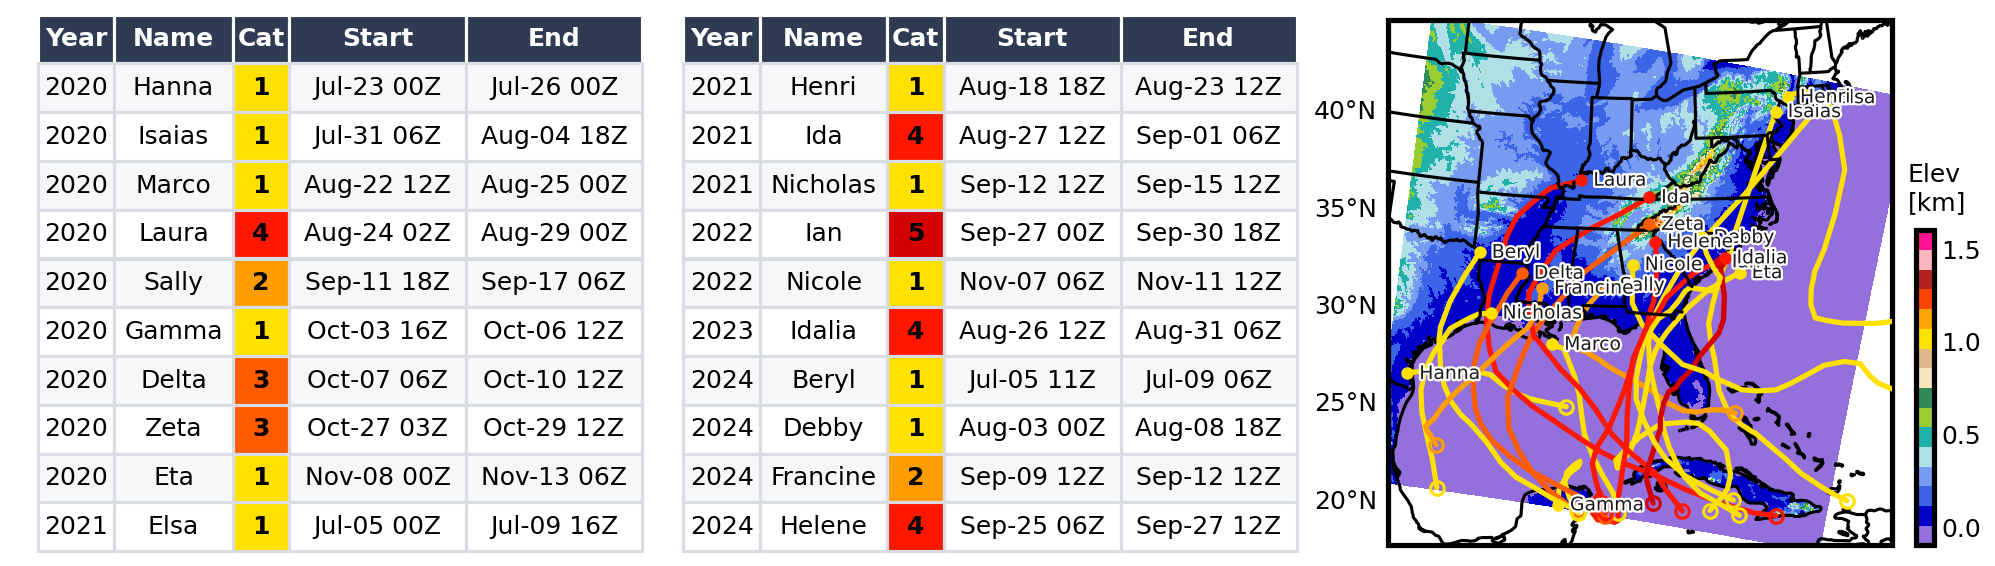

In [16]:
cmap_elev = cmaps.amwg

scale_param = '50m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param), edgecolor='k', linewidth=1.5, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

proj = ccrs.LambertConformal(central_longitude=-83, central_latitude=35, standard_parallels=(20,40))
#ccrs.LambertConformal(central_longitude=-83, central_latitude=35, standard_parallels=(20,40))
#ccrs.PlateCarree()
proj_data = data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 3.5), dpi=dpi_)
gs = gridspec.GridSpec(1, 3, height_ratios=[1,], width_ratios=[1, 1, 1]) #0.86

# --- Panel (a): top-left table (first half of rows) ---
ax_tab1 = fig.add_subplot(gs[:, 0])
# --- Panel (b): bottom-left table (second half of rows) ---
ax_tab2 = fig.add_subplot(gs[:, 1])
# --- Panel (c): map spanning both rows on the right ---
ax_map = fig.add_subplot(gs[0, 2], projection=proj)

plt.subplots_adjust(0, 0, 1, 1, hspace=0, wspace=0)

# ax_tab1.set_title("(a) Hurricane Cases (1/2)", fontsize=12)
# ax_tab2.set_title("(b) Hurricane Cases (2/2)", fontsize=12)
# ax_map.set_title("(c) Elevation & HURDAT Tracks", fontsize=12)

# ============================================================
# MAP PANEL
# ============================================================
ax_map.set_extent(map_extent, crs=proj_data)
ax_map = map_gridline_opt(ax_map)

GL = ax_map.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, y_inline=False,
    color=None, linewidth=0, zorder=5)

GL.xlabel_style = {'size': 12}
GL.ylabel_style = {'size': 12}
GL.top_labels = None
GL.bottom_labels = None
GL.right_labels = None
GL.rotate_labels = False

CS = ax_map.pcolormesh(xlon, xlat, 1e-3*elev, vmin=-0.1, vmax=1.6,
                       cmap=cmap_elev, transform=ccrs.PlateCarree())

# ax_map.text(0.935, -0.015, 'Elev [km]', ha='left', va='top', fontsize=12, transform=ax_map.transAxes)
ax_map.text(1.03, 0.63, 'Elev\n[km]', ha='left', va='bottom', fontsize=12, transform=ax_map.transAxes)

ax_base1 = fig.add_axes([0.975, 0.0, 0.03, 0.6])
ax_base1.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False,
    labelleft=False, labeltop=False, labelright=False, labelbottom=False)
cax1 = inset_axes(ax_base1, height='100%', width='30%', borderpad=0, loc=2)
CBar1 = plt.colorbar(CS, orientation='vertical', cax=cax1, ticks=[0, 0.5, 1, 1.5])
CBar1.ax.tick_params(axis='y', labelsize=12, direction='in', length=0)
CBar1.outline.set_linewidth(2.5)
ax_base1.set_axis_off()

# --- Tracks ---
lons = np.concatenate([t["lon"] for t in tracks])
lats = np.concatenate([t["lat"] for t in tracks])
pad = 2.5
x0, x1 = lons.min() - pad, lons.max() + pad
y0, y1 = lats.min() - pad, lats.max() + pad

for tr in tracks:
    col = cat_color(tr["cat"])
    lon, lat = tr["lon"], tr["lat"]
    ax_map.plot(lon, lat, "-", color=col, lw=2.5, transform=data_crs,
                solid_capstyle="round", solid_joinstyle="round", zorder=5)
    # start
    ax_map.plot(lon[0], lat[0], "o", mfc="none", mec=col, mew=1.5, ms=6.5,
                transform=data_crs, zorder=7)
    # end
    ax_map.plot(lon[-1], lat[-1], "o", color=col, mec="none", mew=1, ms=6,
                transform=data_crs, zorder=7)

    frac = (lon[-1] - x0) / (x1 - x0)
    label, ha = (tr["name"] + "  ", "right") if frac > 0.80 else ("  " + tr["name"], "left")

    txt = ax_map.text(lon[-1], lat[-1], label, transform=data_crs, fontsize=9,
                      color="#1a1a1a", ha=ha, va="center", zorder=8, clip_on=False)
    txt.set_path_effects([pe.withStroke(linewidth=2.2, foreground="white")])

# ============================================================
# TABLE PANELS — split raw_cases into two halves
# ============================================================
n_rows = len(raw_cases)
mid = n_rows // 2 + (1 if n_rows % 2 else 0)  # ceiling split
raw_cases_top = raw_cases[:mid]
raw_cases_bot = raw_cases[mid:]

col_labels = ["Year", "Name", "Cat", "Start", "End"]
ncol = len(col_labels)

def build_table(ax, cases, col_labels):
    """Draw a styled table on the given axes and return the table object."""
    ax.axis("off")
    cell_text = [
        [str(season), name, str(cat), fmt_t(ts), fmt_t(te)]
        for season, sid, name, cat, ts, te in cases
    ]
    tbl = ax.table(cellText=cell_text, colLabels=col_labels,
                   cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(1.0, 1.5)

    # Header row
    for j in range(ncol):
        hc = tbl[0, j]
        hc.set_facecolor("#2f3b52")
        hc.set_text_props(color="white", weight="bold")
        hc.set_edgecolor("white")
        hc.set_linewidth(1.5)
        hc.set_height(hc.get_height() * 1.3)

    # Data rows
    for row_i, (season, sid, name, cat, ts, te) in enumerate(cases, start=1):
        for j in range(ncol):
            cell = tbl[row_i, j]
            cell.set_edgecolor("#d9dde3")
            cell.set_linewidth(1.5)
            cell.set_height(cell.get_height() * 1.3)
            if j == 2:  # Cat column
                cell.set_facecolor(cat_color(cat))
                cell.set_text_props(weight="bold")
            else:
                cell.set_facecolor("#f6f7f9" if row_i % 2 else "white")

    tbl.auto_set_column_width(col=list(range(ncol)))
    return tbl

build_table(ax_tab1, raw_cases_top, col_labels)
build_table(ax_tab2, raw_cases_bot, col_labels)

# # ============================================================
# # LEGEND (x)
# # ============================================================
# present = sorted({t["cat"] for t in tracks})
# handles = [Line2D([0], [0], color=cat_color(c), lw=3, label=SSHWS_LABEL[c])
#            for c in present]
# handles += [
#     Line2D([0], [0], marker="o", mfc="white", mec="#444", mew=1.3,
#            ls="none", ms=6.5, label="genesis"),
#     Line2D([0], [0], marker="o", color="#444", mec="white",
#            ls="none", ms=6, label="window end"),
# ]